#Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

#Cargar el dataset

In [2]:
df = pd.read_csv("/content/Wine dataset.csv")

df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


#Descripción del dataset

In [3]:
print("Número de observaciones:", df.shape[0])
print("Número de variables:", df.shape[1])

print("\nVariables")
print(df.columns)

print("\nClases")
print(df["class"].value_counts())

Número de observaciones: 178
Número de variables: 14

Variables
Index(['class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline '],
      dtype='object')

Clases
class
2    71
1    59
3    48
Name: count, dtype: int64


#Exploración de datos

In [4]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

#Distribución de clases

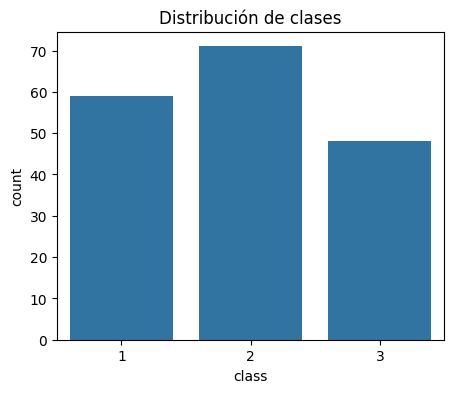

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x="class", data=df)

plt.title("Distribución de clases")
plt.show()

#Histogramas

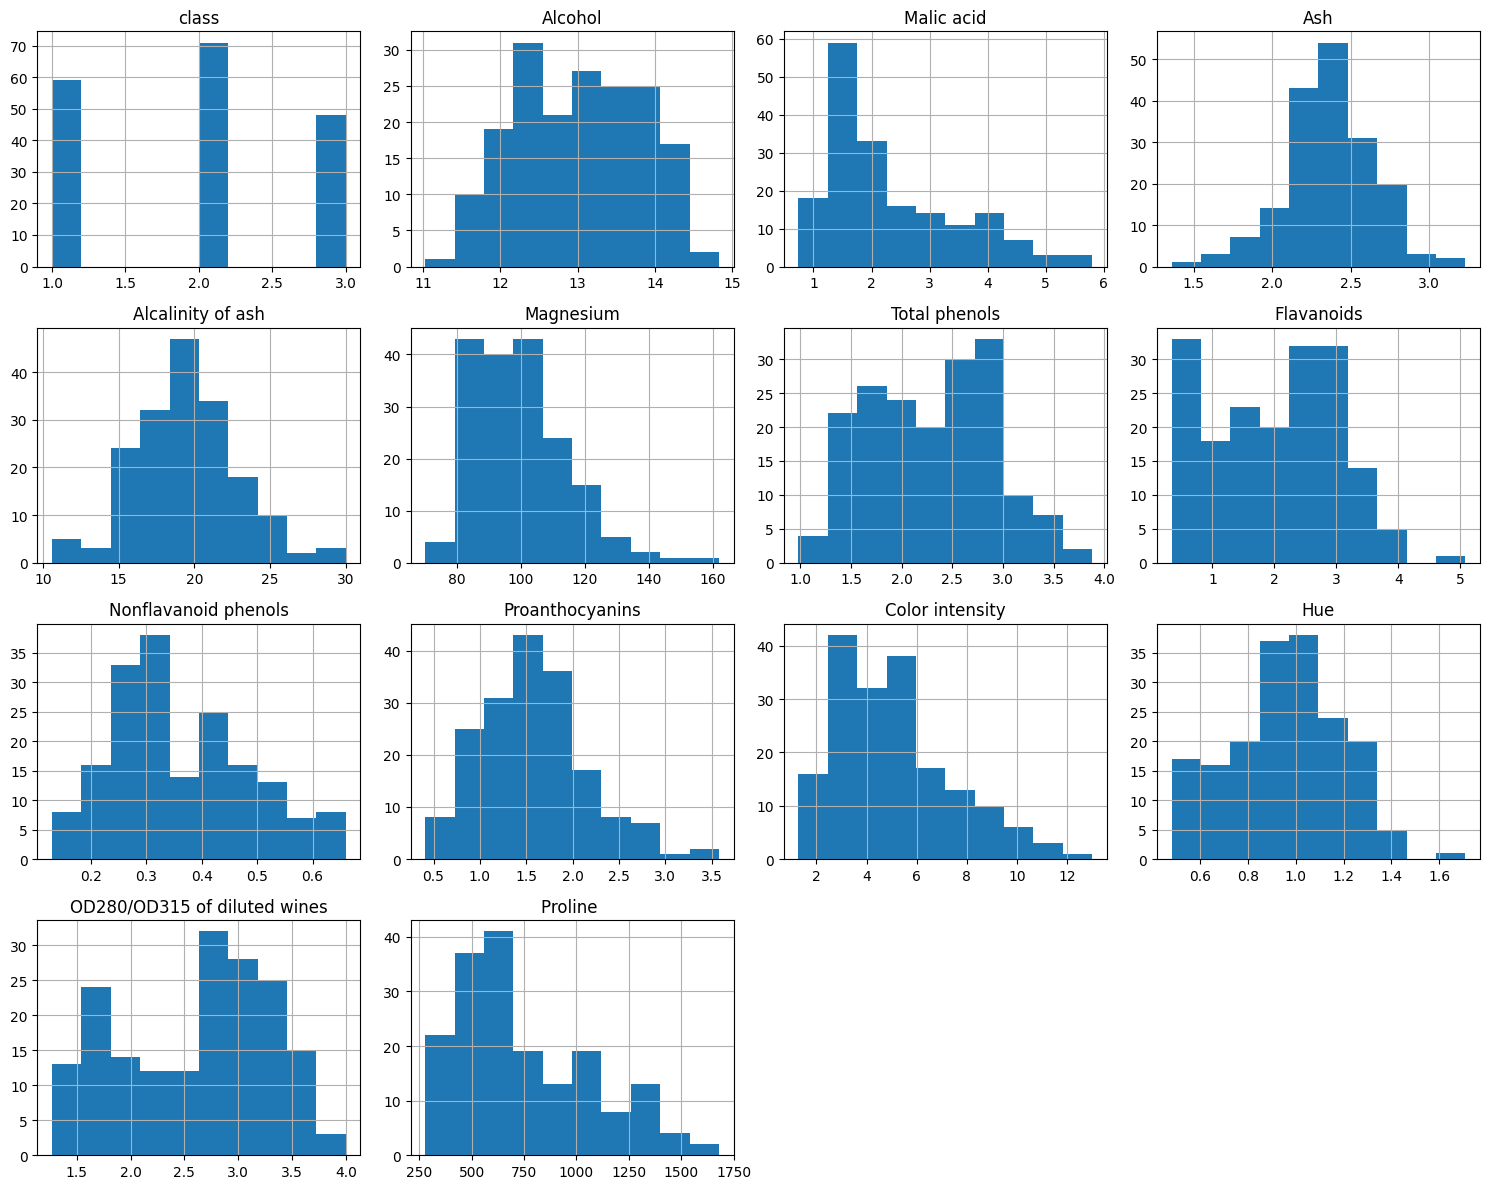

In [6]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

#Boxplots

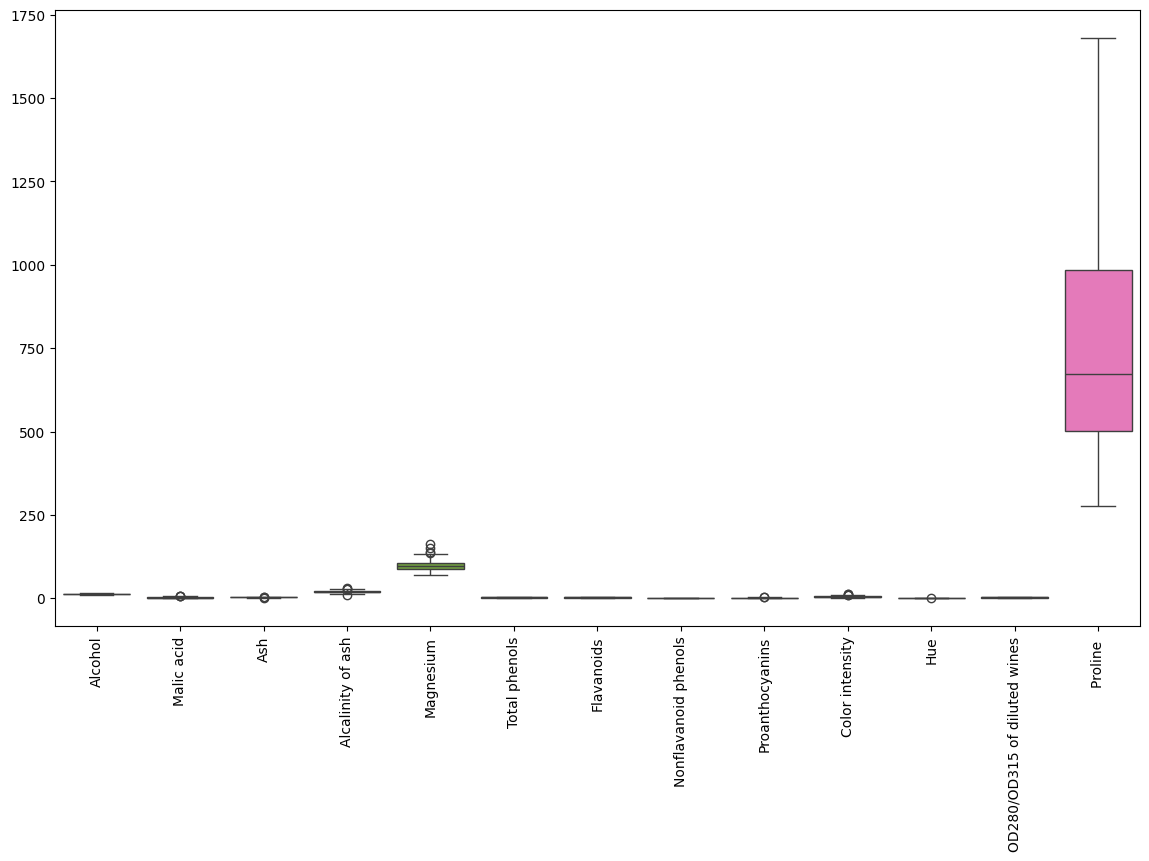

In [7]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df.drop("class",axis=1))
plt.xticks(rotation=90)
plt.show()

#Mapa de correlación

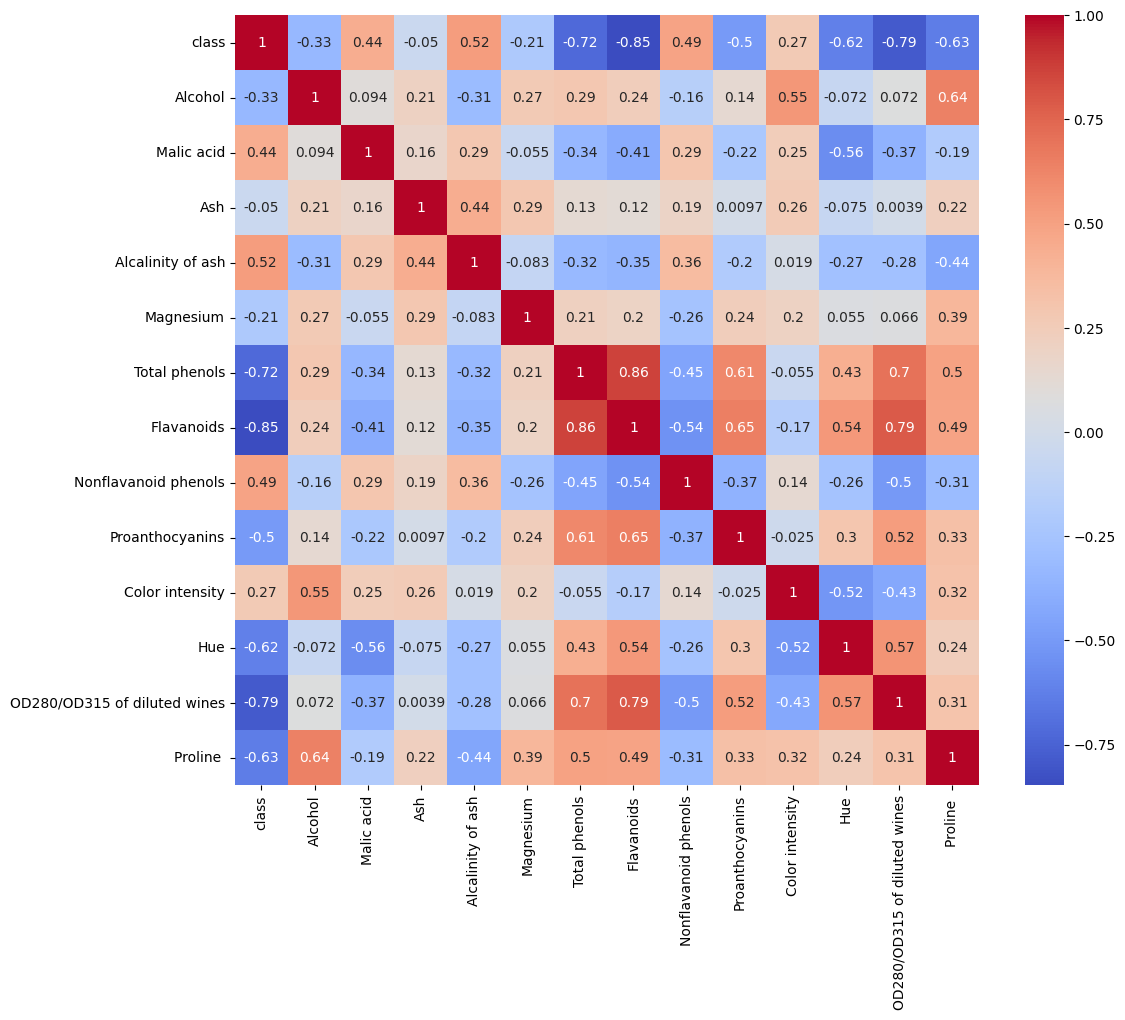

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

#Preparación de datos

In [9]:
X = df.drop("class",axis=1)
y = df["class"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#Estandarización

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Modelo LDA

In [11]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train,y_train)

pred_lda = lda.predict(X_test)

#Resultados LDA

In [12]:
print("Accuracy:",accuracy_score(y_test,pred_lda))
print("Precision:",precision_score(y_test,pred_lda,average="weighted"))
print("Recall:",recall_score(y_test,pred_lda,average="weighted"))
print("F1:",f1_score(y_test,pred_lda,average="weighted"))

print(classification_report(y_test,pred_lda))

Accuracy: 0.9814814814814815
Precision: 0.9824561403508772
Recall: 0.9814814814814815
F1: 0.9815058961400425
              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       1.00      0.95      0.98        21
           3       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



#Matriz de confusión LDA

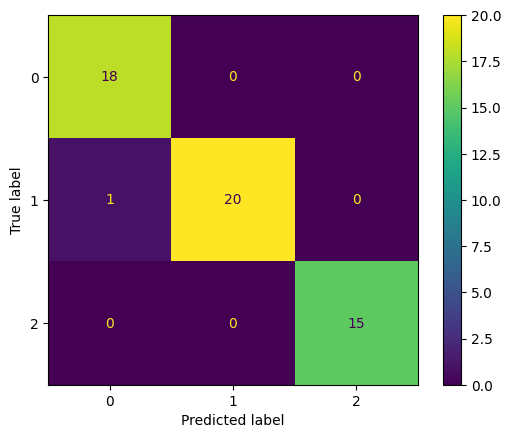

In [13]:
cm = confusion_matrix(y_test,pred_lda)

ConfusionMatrixDisplay(cm).plot()

plt.show()

#Modelo QDA

In [14]:
qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train,y_train)

pred_qda = qda.predict(X_test)

#Resultados QDA

In [15]:
print("Accuracy:",accuracy_score(y_test,pred_qda))
print("Precision:",precision_score(y_test,pred_qda,average="weighted"))
print("Recall:",recall_score(y_test,pred_qda,average="weighted"))
print("F1:",f1_score(y_test,pred_qda,average="weighted"))

print(classification_report(y_test,pred_qda))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



#Matriz de confusión QDA

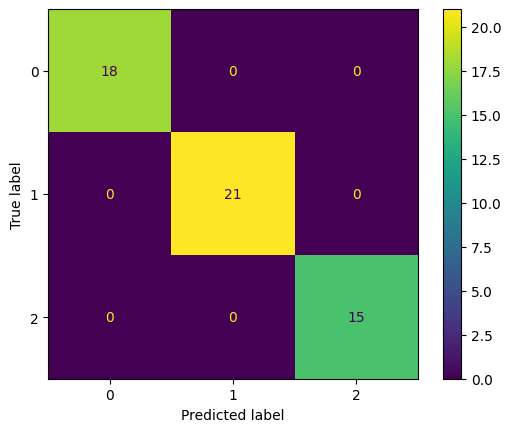

In [16]:
cm = confusion_matrix(y_test,pred_qda)

ConfusionMatrixDisplay(cm).plot()

plt.show()

#Comparación de modelos

In [17]:
comparacion = pd.DataFrame({

    "Modelo":["LDA","QDA"],

    "Accuracy":[
        accuracy_score(y_test,pred_lda),
        accuracy_score(y_test,pred_qda)
    ],

    "Precision":[
        precision_score(y_test,pred_lda,average="weighted"),
        precision_score(y_test,pred_qda,average="weighted")
    ],

    "Recall":[
        recall_score(y_test,pred_lda,average="weighted"),
        recall_score(y_test,pred_qda,average="weighted")
    ],

    "F1":[
        f1_score(y_test,pred_lda,average="weighted"),
        f1_score(y_test,pred_qda,average="weighted")
    ]

})

comparacion

,Modelo,Accuracy,Precision,Recall,F1
0,LDA,0.981481,0.982456,0.981481,0.981506
1,QDA,1.000000,1.000000,1.000000,1.000000


#Fronteras de decisión

In [18]:
X = df[['Alcohol','Color intensity']]
y = df['class']

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda.fit(X_train,y_train)
qda.fit(X_train,y_train)

QuadraticDiscriminantAnalysis()

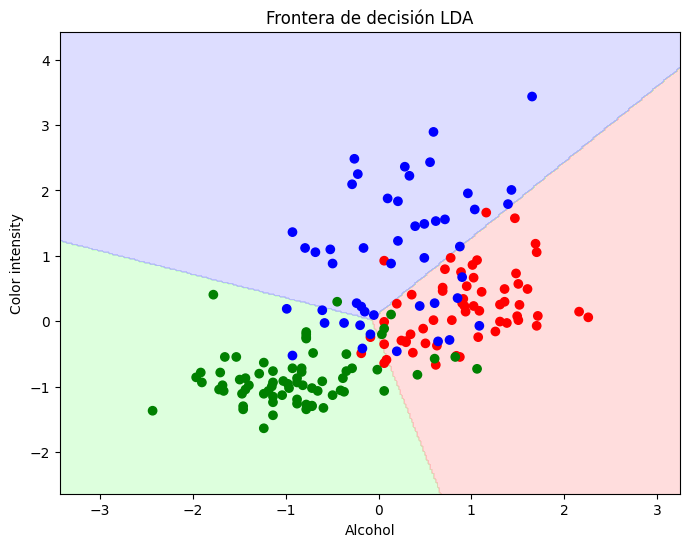

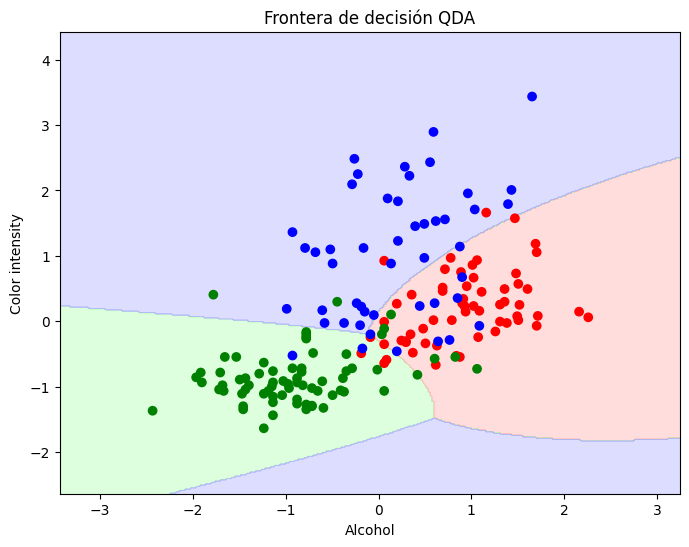

In [19]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, titulo):

    h=0.02

    x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
    y_min,y_max=X[:,1].min()-1,X[:,1].max()+1

    xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                      np.arange(y_min,y_max,h))

    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.contourf(xx,yy,Z,alpha=0.4,cmap=ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF']))

    plt.scatter(X[:,0],X[:,1],c=y,cmap=ListedColormap(['red','green','blue']))

    plt.title(titulo)

    plt.xlabel("Alcohol")

    plt.ylabel("Color intensity")

    plt.show()

plot_decision_boundary(lda,X,y,"Frontera de decisión LDA")

plot_decision_boundary(qda,X,y,"Frontera de decisión QDA")

#Conclusiones Finales
1. El modelo LDA obtuvo un excelente desempeño al clasificar las muestras del conjunto de datos Wine, alcanzando un accuracy de 98.15 %, además de valores muy altos de precisión, recall y F1-score. Esto demuestra que el modelo fue capaz de identificar correctamente la gran mayoría de las observaciones.

2. El modelo QDA presentó el mejor desempeño de la comparación, logrando un accuracy, precisión, recall y F1-score del 100 %. Estos resultados indican que clasificó correctamente todas las muestras del conjunto de prueba, sin cometer errores de clasificación.

3. Los resultados muestran que los supuestos estadísticos influyen directamente en el rendimiento de los modelos. En este conjunto de datos, permitir que cada clase tenga una matriz de covarianza diferente favoreció a QDA, ya que pudo adaptarse mejor a la distribución de las observaciones y obtener una clasificación perfecta.

4. Al comparar ambos modelos, se observa que los dos ofrecen un desempeño muy alto; sin embargo, QDA superó ligeramente a LDA en todas las métricas de evaluación. Esto evidencia que, para el dataset Wine utilizado en esta práctica, la mayor flexibilidad de QDA representó una ventaja frente al enfoque lineal de LDA.

5. Las fronteras de decisión permitieron visualizar claramente la diferencia entre ambos algoritmos. LDA generó límites lineales entre las clases, mientras que QDA produjo fronteras curvas que se ajustan mejor a la distribución de los datos. Esto confirma que la elección entre ambos modelos depende de las características del conjunto de datos y de si las clases presentan una estructura de covarianza similar o diferente.